In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import csv

# Load the dataset
data24 = pd.read_csv(r"C:\Users\masjk\Downloads\Delayed_Cancelled_Flights (1).csv")
data23 = pd.read_csv(r'C:\Users\masjk\Downloads\Delayed_Cancelled_Flights_2023.csv')
#data24.head()
#data23.head()

data = pd.concat([data24, data23], ignore_index=True)
data.head()

,FL_DATE,MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,DEP_DELAY,ARR_DELAY,CANCELLED,CANCELLATION_CODE,WEATHER_DELAY,NAS_DELAY,CARRIER_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DELAYED
0,2/1/2024 12:00:00 AM,2,4,9E,4865.0,MEM,LGA,-5.0,28.0,0.0,NaN,0.0,28.0,0.0,0.0,0.0,True
1,2/1/2024 12:00:00 AM,2,4,9E,4906.0,LGA,PIT,121.0,112.0,0.0,NaN,0.0,0.0,112.0,0.0,0.0,True
2,2/1/2024 12:00:00 AM,2,4,9E,4912.0,DHN,ATL,167.0,154.0,0.0,NaN,0.0,0.0,0.0,0.0,154.0,True
3,2/1/2024 12:00:00 AM,2,4,9E,4916.0,LGA,DSM,30.0,18.0,0.0,NaN,0.0,0.0,18.0,0.0,0.0,True
4,2/1/2024 12:00:00 AM,2,4,9E,4944.0,ATL,DHN,0.0,29.0,0.0,NaN,0.0,29.0,0.0,0.0,0.0,True


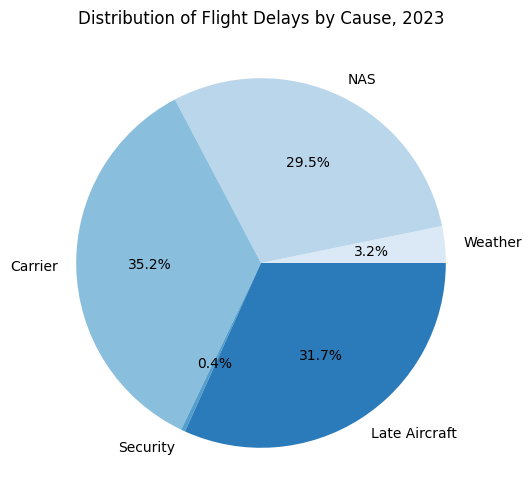

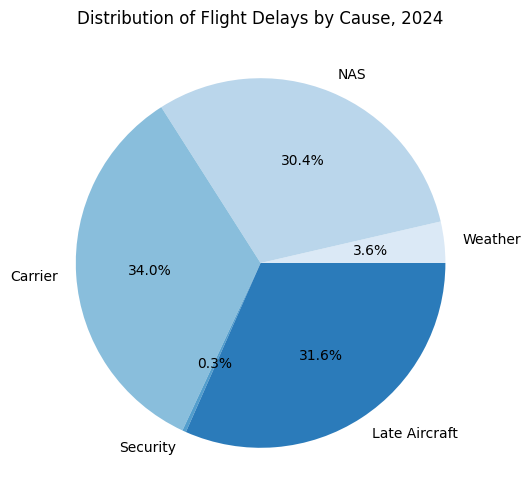

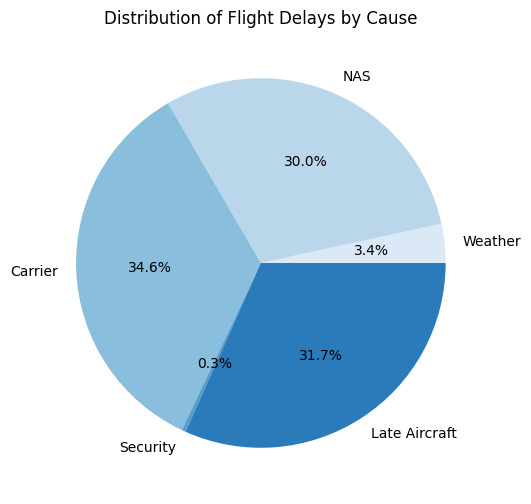

In [25]:
#DIVIDING INTO DELAY TYPES 

weather23 = data23[data23['WEATHER_DELAY'] > 0]
nas23 = data23[data23['NAS_DELAY'] > 0]
carrier23 = data23[data23['CARRIER_DELAY'] > 0]
security23 = data23[data23['SECURITY_DELAY'] > 0]
late_aircraft23 = data23[data23['LATE_AIRCRAFT_DELAY'] > 0]
weather24 = data24[data24['WEATHER_DELAY'] > 0]
nas24 = data24[data24['NAS_DELAY'] > 0]
carrier24 = data24[data24['CARRIER_DELAY'] > 0]
security24 = data24[data24['SECURITY_DELAY'] > 0]
late_aircraft24 = data24[data24['LATE_AIRCRAFT_DELAY'] > 0]
weather = pd.concat([weather23, weather24], ignore_index=True)
nas = pd.concat([nas23, nas24], ignore_index=True)
carrier = pd.concat([carrier23, carrier24], ignore_index=True)
security = pd.concat([security23, security24], ignore_index=True)
late_aircraft = pd.concat([late_aircraft23, late_aircraft24], ignore_index=True)

plt.figure(figsize=(10, 6))
plt.pie([len(weather23), len(nas23), len(carrier23), len(security23), len(late_aircraft23)],
        labels=['Weather', 'NAS', 'Carrier', 'Security', 'Late Aircraft'], colors=sns.color_palette('Blues'), autopct='%1.1f%%')
plt.title('Distribution of Flight Delays by Cause, 2023')
plt.show()

plt.figure(figsize=(10, 6))
plt.pie([len(weather24), len(nas24), len(carrier24), len(security24), len(late_aircraft24)],
        labels=['Weather', 'NAS', 'Carrier', 'Security', 'Late Aircraft'], colors=sns.color_palette('Blues'), autopct='%1.1f%%')
plt.title('Distribution of Flight Delays by Cause, 2024')
plt.show()

plt.figure(figsize=(10, 6))
plt.pie([len(weather), len(nas), len(carrier), len(security), len(late_aircraft)],
        labels=['Weather', 'NAS', 'Carrier', 'Security', 'Late Aircraft'], colors=sns.color_palette('Blues'), autopct='%1.1f%%')
plt.title('Distribution of Flight Delays by Cause')
plt.show()


               Delay Pair   Count
8   Carrier&Late Aircraft  370353
4             NAS&Carrier  300504
6       NAS&Late Aircraft  276182
0             Weather&NAS   44261
3   Weather&Late Aircraft   33659
5            NAS&Security    3650
9  Security&Late Aircraft    3592
1         Weather&Carrier    2963
7        Carrier&Security     688
2        Weather&Security      24


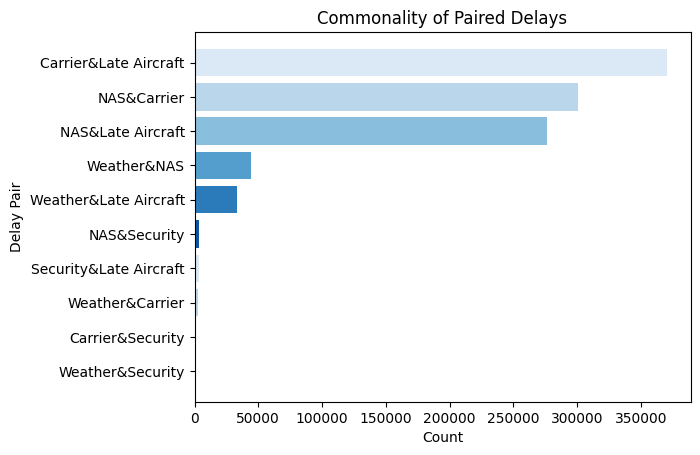

In [26]:
#PAIRED DELAYS

paired_delays = {"Weather&NAS": 0, "Weather&Carrier": 0, "Weather&Security": 0, "Weather&Late Aircraft": 0,
                 "NAS&Carrier": 0, "NAS&Security": 0, "NAS&Late Aircraft": 0, "Carrier&Security": 0, "Carrier&Late Aircraft": 0, "Security&Late Aircraft": 0}


with open(r'C:\Users\masjk\Downloads\Delayed_Cancelled_Flights.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        weather = float(row['WEATHER_DELAY'] or 0)
        nas = float(row['NAS_DELAY'] or 0)
        carrier = float(row['CARRIER_DELAY'] or 0)
        security = float(row['SECURITY_DELAY'] or 0)
        late = float(row['LATE_AIRCRAFT_DELAY'] or 0)
        if weather > 0 and nas > 0:
            paired_delays["Weather&NAS"] += 1
        if weather > 0 and carrier > 0:
            paired_delays["Weather&Carrier"] += 1
        if weather > 0 and security > 0:
            paired_delays["Weather&Security"] += 1
        if weather > 0 and late > 0:
            paired_delays["Weather&Late Aircraft"] += 1
        if nas > 0 and carrier > 0:
            paired_delays["NAS&Carrier"] += 1
        if nas > 0 and security > 0:
            paired_delays["NAS&Security"] += 1
        if nas > 0 and late > 0:
            paired_delays["NAS&Late Aircraft"] += 1
        if carrier > 0 and security > 0:
            paired_delays["Carrier&Security"] += 1
        if carrier > 0 and late > 0:
            paired_delays["Carrier&Late Aircraft"] += 1
        if security > 0 and late > 0:
            paired_delays["Security&Late Aircraft"] += 1
        

paired_delays_df = pd.DataFrame(list(paired_delays.items()), columns=['Delay Pair', 'Count'])
paired_delays_df_sorted = paired_delays_df.sort_values(by='Count', ascending=False)
print(paired_delays_df_sorted)

plt.barh(paired_delays_df_sorted['Delay Pair'], paired_delays_df_sorted['Count'], color=sns.color_palette('Blues'))
plt.xlabel('Count')
plt.ylabel('Delay Pair')
plt.title("Commonality of Paired Delays")
plt.gca().invert_yaxis()
plt.show()

In [27]:
top10_2023 = data23["ORIGIN"].value_counts().head(10)
top10_2024 = data24["ORIGIN"].value_counts().head(10)
top10 = pd.concat([top10_2023, top10_2024], axis=1, keys=['2023', '2024'])
# print(top10_2023)
# print(top10_2024)
#print(top10)
top10_2024

ORIGIN
DFW    86025
DEN    73272
ORD    67313
ATL    66918
CLT    58059
LAS    42651
MCO    41107
PHX    38295
LAX    38002
SEA    36095
Name: count, dtype: int64

In [28]:
#top 10 airports 
DFW = data[data['ORIGIN'] == 'DFW']
ATL = data[data['ORIGIN'] == 'ATL']
DEN = data[data['ORIGIN'] == 'DEN']
ORD = data[data['ORIGIN'] == 'ORD']
CLT = data[data['ORIGIN'] == 'CLT']
LAS = data[data['ORIGIN'] == 'LAS']
LAX = data[data['ORIGIN'] == 'LAX']
SEA = data[data['ORIGIN'] == 'SEA']
MCO = data[data['ORIGIN'] == 'MCO']
EWR = data[data['ORIGIN'] == 'EWR']

top10_airports = [DFW, ATL, DEN, ORD, CLT, LAS, LAX, SEA, MCO, EWR]

In [29]:
#finding each airport's total delay by type
DFW_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
ATL_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
DEN_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
ORD_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
CLT_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
LAS_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
LAX_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
SEA_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
MCO_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
EWR_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}

delay_cols = [
    'WEATHER_DELAY',
    'NAS_DELAY',
    'CARRIER_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]

# Make sure all delay columns are numeric
DFW[delay_cols] = DFW[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
ATL[delay_cols] = ATL[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
DEN[delay_cols] = DEN[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
ORD[delay_cols] = ORD[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
CLT[delay_cols] = CLT[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
LAS[delay_cols] = LAS[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
LAX[delay_cols] = LAX[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
SEA[delay_cols] = SEA[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
MCO[delay_cols] = MCO[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
EWR[delay_cols] = EWR[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Total delays per type for each airport
DFW_delays = DFW[delay_cols].sum().to_dict()
ATL_delays = ATL[delay_cols].sum().to_dict()
DEN_delays = DEN[delay_cols].sum().to_dict()
ORD_delays = ORD[delay_cols].sum().to_dict()
CLT_delays = CLT[delay_cols].sum().to_dict()
LAS_delays = LAS[delay_cols].sum().to_dict()
LAX_delays = LAX[delay_cols].sum().to_dict()
SEA_delays = SEA[delay_cols].sum().to_dict()
MCO_delays = MCO[delay_cols].sum().to_dict()
EWR_delays = EWR[delay_cols].sum().to_dict()

#SIMPLER WAY
top10_codes = ['DFW','ATL','DEN','ORD','CLT','LAS','LAX','SEA','MCO','EWR']

totals = (
    data[data['ORIGIN'].isin(top10_codes)]
    .groupby('ORIGIN')[delay_cols]
    .sum()
)

averages = (
    data[data['ORIGIN'].isin(top10_codes)]
    .groupby('ORIGIN')[delay_cols]
    .mean()
)

print(totals)
print(averages)

C:\Users\masjk\AppData\Local\Temp\ipykernel_26732\3367664572.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DFW[delay_cols] = DFW[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
C:\Users\masjk\AppData\Local\Temp\ipykernel_26732\3367664572.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ATL[delay_cols] = ATL[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
C:\Users\masjk\AppData\Local\Temp\ipykernel_26732\3367664572.py:24: SettingWithCopyWarning: 
A value is trying to be set

        WEATHER_DELAY  NAS_DELAY  CARRIER_DELAY  SECURITY_DELAY  \
ORIGIN                                                            
ATL          406524.0  1491138.0      3855567.0         10678.0   
CLT          473113.0  1004806.0      2206769.0         28733.0   
DEN          395208.0  1408007.0      3188186.0         12496.0   
DFW          751381.0  1486341.0      3575784.0         14571.0   
EWR          226767.0   990042.0      1495423.0          5391.0   
LAS          152027.0  1108651.0      1881384.0          8525.0   
LAX          133338.0   918453.0      1881380.0          8280.0   
MCO          419673.0  1300376.0      1911732.0         27548.0   
ORD          533160.0  1601639.0      2815511.0          8333.0   
SEA          186901.0   747886.0      1534725.0          9691.0   

        LATE_AIRCRAFT_DELAY  
ORIGIN                       
ATL               2267524.0  
CLT               3350306.0  
DEN               3840701.0  
DFW               5003098.0  
EWR            

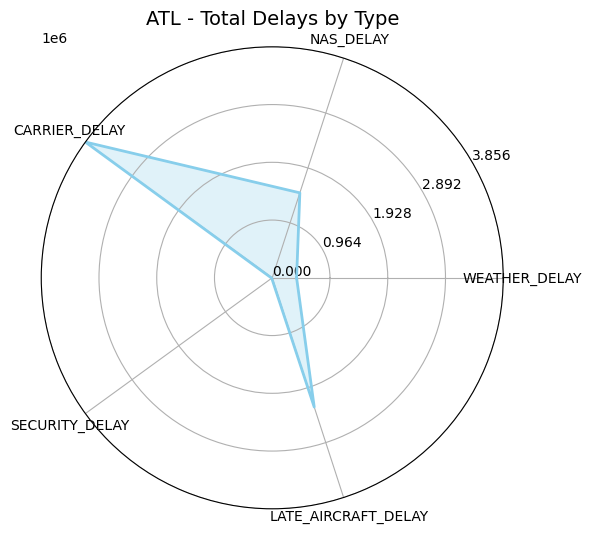

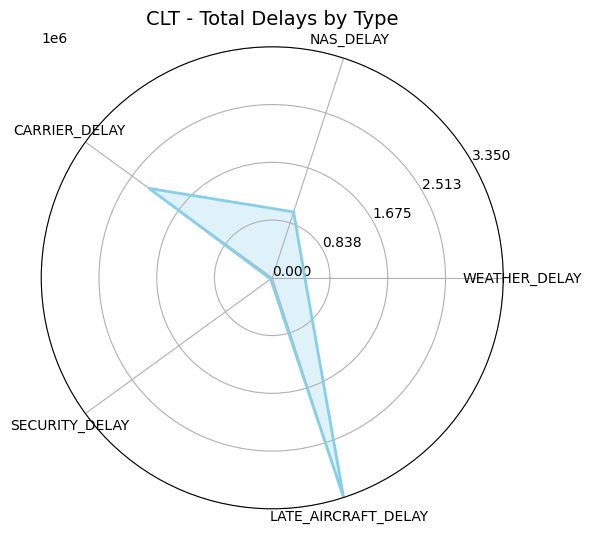

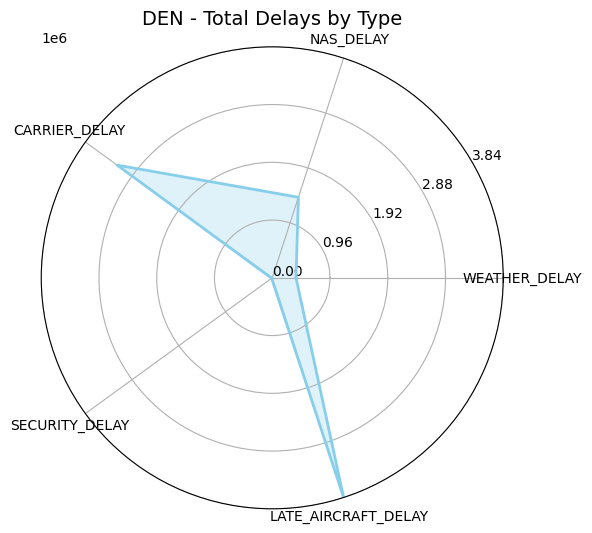

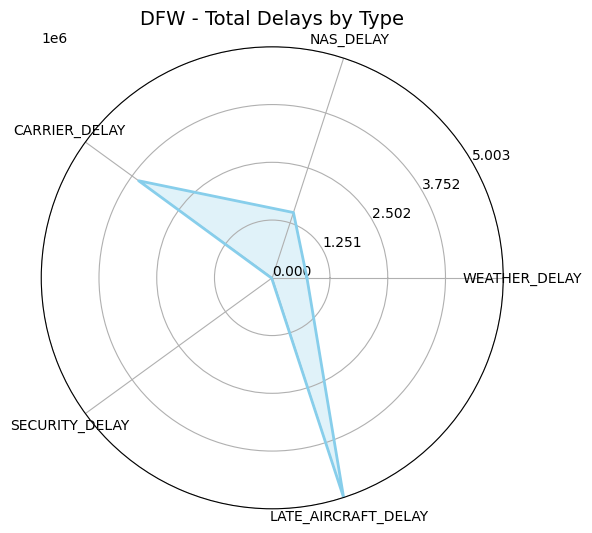

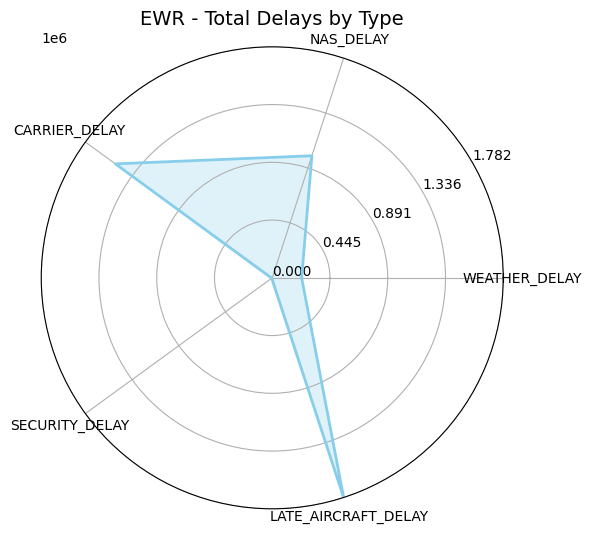

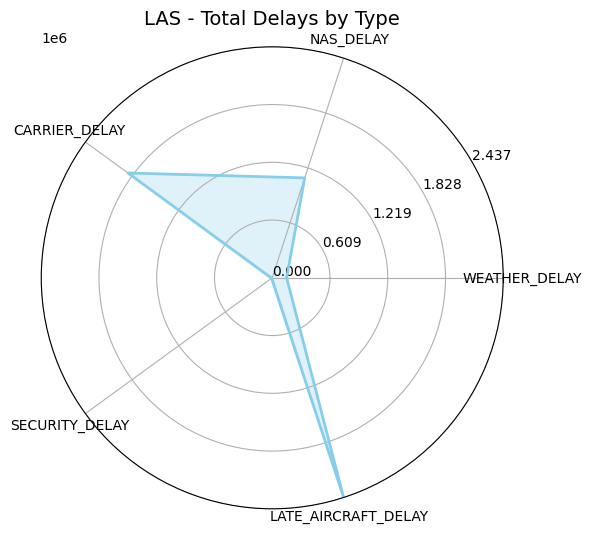

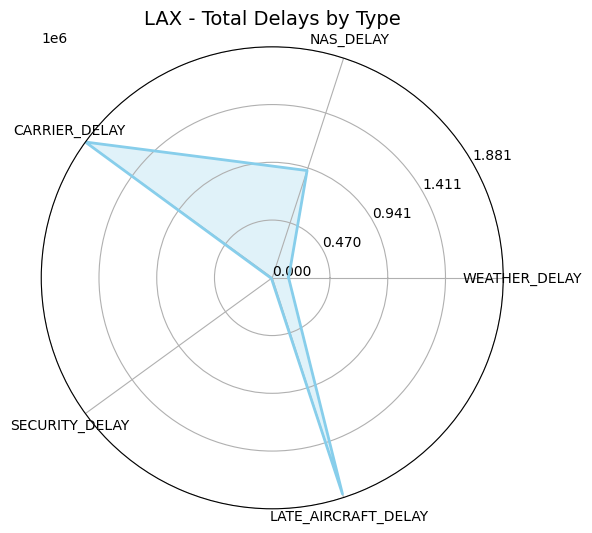

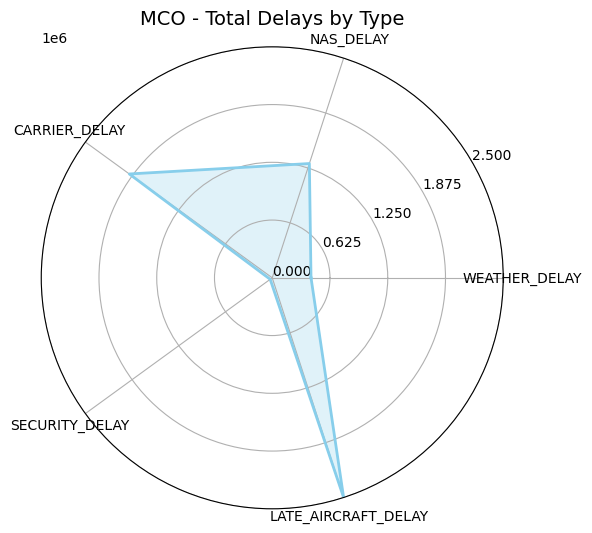

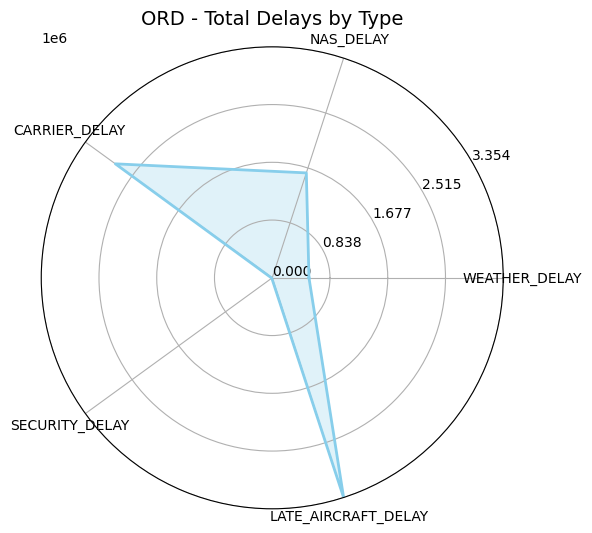

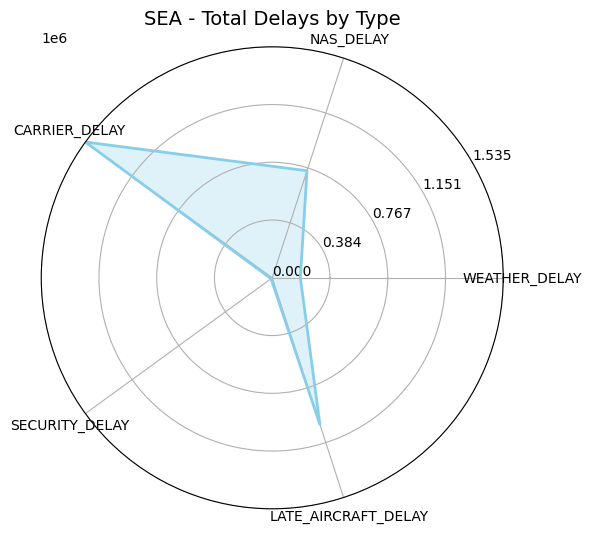

In [30]:
def plot_radar(data, airport_name, color='skyblue'):
    categories = list(data.index)
    values = data.values.flatten().tolist()
    
    # Close the circle
    values += values[:1]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    
    ax.plot(angles, values, color=color, linewidth=2, label=airport_name)
    ax.fill(angles, values, color=color, alpha=0.25)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    
    # Optional: make y-axis start at 0
    ax.set_rlabel_position(30)
    ax.set_yticks(np.linspace(0, max(values), 5))
    ax.set_ylim(0, max(values))
    
    plt.title(f"{airport_name} - Total Delays by Type", size=14)
    plt.show()

for airport in totals.index:
    plot_radar(totals.loc[[airport]].T, airport)

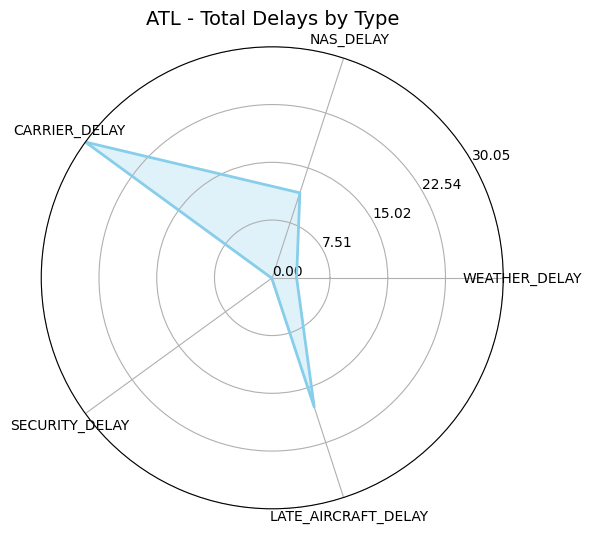

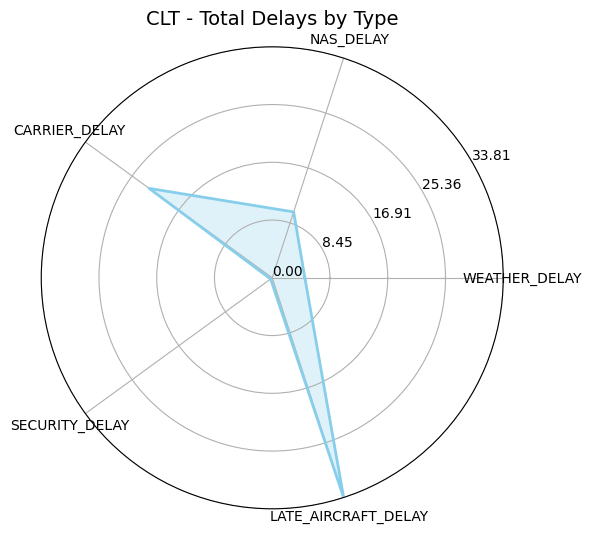

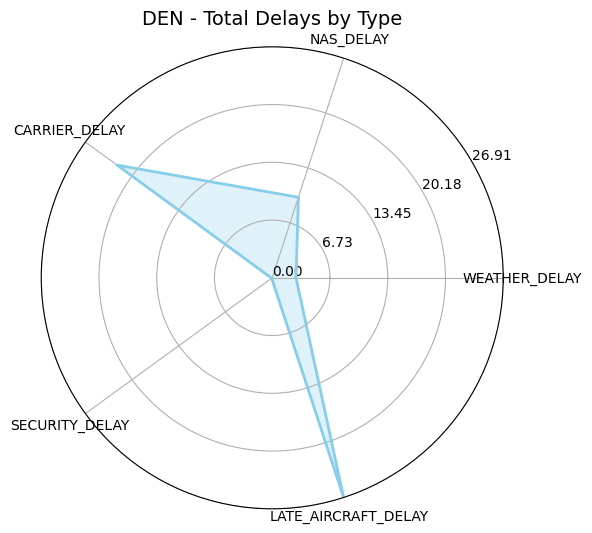

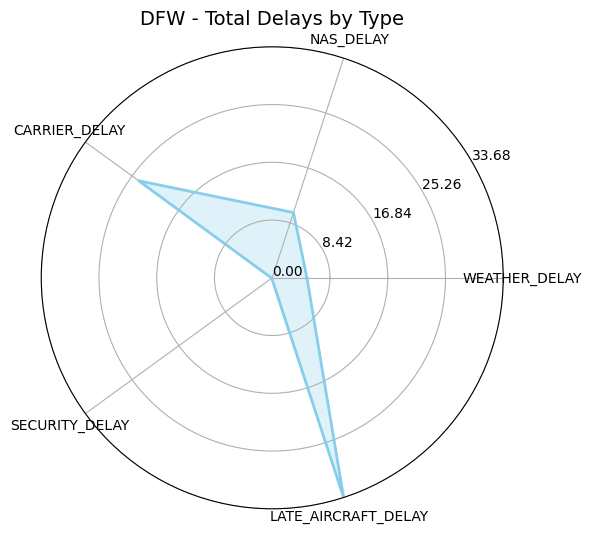

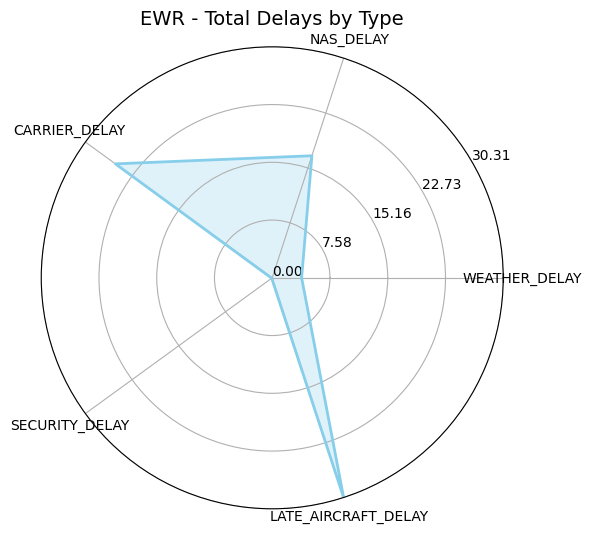

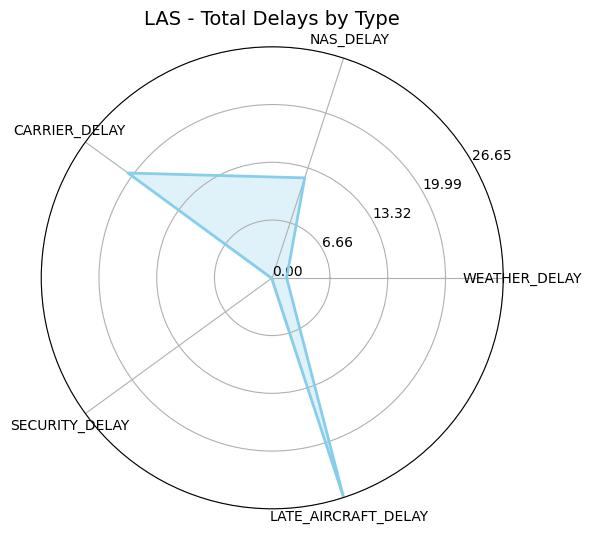

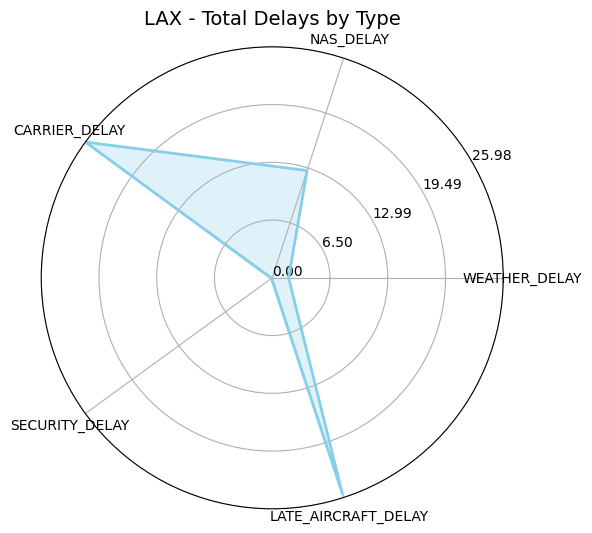

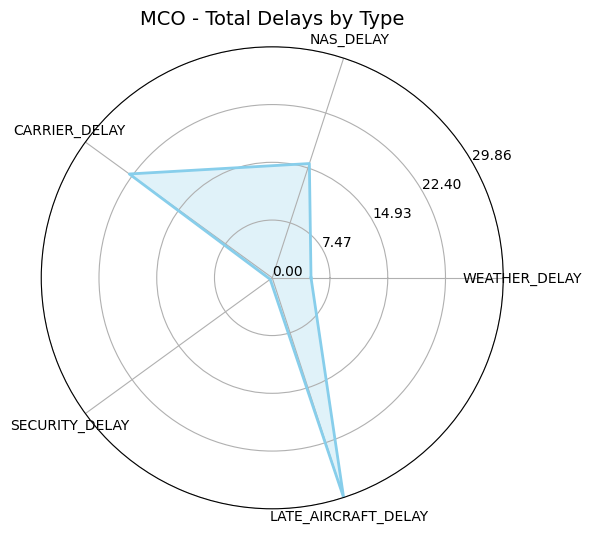

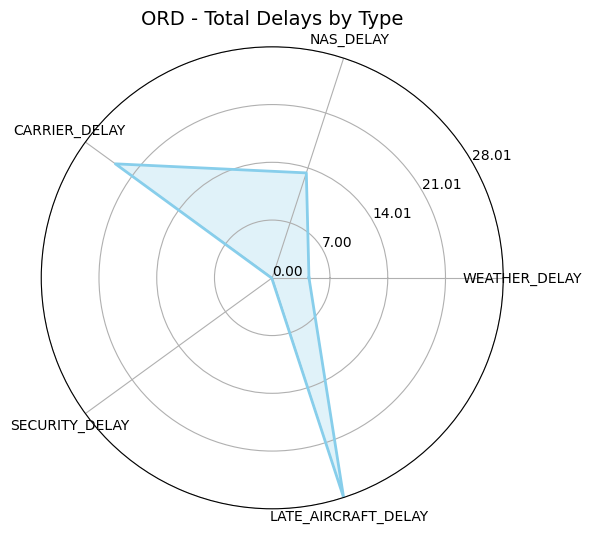

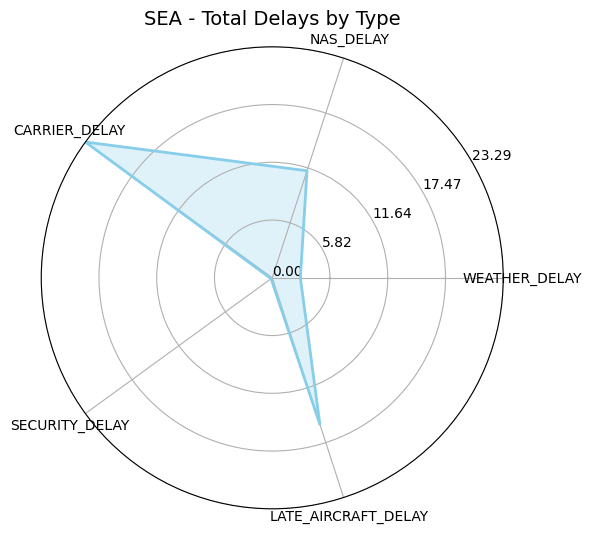

In [31]:
for airport in averages.index:
    plot_radar(averages.loc[[airport]].T, airport)

In [32]:
#STILL TO ADD: Radar/Spider plot for each of top 10 airports by total/avg delay length by type, Most commonly delayed routes, Stacked bar chart of delay types by airport, heatmap?


In [ ]:
#CARRIER ANALYSIS I- MERGING WITH LOOKUP CSV
lookup = pd.read_csv(
    r"C:\Users\masjk\Downloads\Carrier_lookup.csv",
    usecols=[0, 1],   # only take first 2 columns
    engine="python"   # more flexible parser
)
lookup.head(20)
data23 = data23.merge(lookup, left_on='OP_UNIQUE_CARRIER', right_on='CARRIER', how='left')
data23 = data23.drop(columns=['CARRIER'])
data24 = data24.merge(lookup, left_on='OP_UNIQUE_CARRIER', right_on='CARRIER', how='left')
data24 = data24.drop(columns=['CARRIER'])
data = data.merge(lookup, left_on='OP_UNIQUE_CARRIER', right_on='CARRIER', how='left')
data = data.drop(columns=['CARRIER'])
data23.head()

,FL_DATE,MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,DEP_DELAY,ARR_DELAY,CANCELLED,CANCELLATION_CODE,WEATHER_DELAY,NAS_DELAY,CARRIER_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DELAYED,CARRIERNAME
0,10/1/2023 12:00:00 AM,10,7,9E,4853,DTW,JFK,16.0,18.0,0.0,NaN,0.0,2.0,2.0,0.0,14.0,True,Endeavor Air Inc.
1,10/1/2023 12:00:00 AM,10,7,9E,4912,ATL,DHN,49.0,47.0,0.0,NaN,0.0,0.0,47.0,0.0,0.0,True,Endeavor Air Inc.
2,10/1/2023 12:00:00 AM,10,7,9E,4912,DHN,ATL,33.0,37.0,0.0,NaN,0.0,4.0,0.0,0.0,33.0,True,Endeavor Air Inc.
3,10/1/2023 12:00:00 AM,10,7,9E,4935,AGS,ATL,228.0,206.0,0.0,NaN,0.0,0.0,206.0,0.0,0.0,True,Endeavor Air Inc.
4,10/1/2023 12:00:00 AM,10,7,9E,4951,DTW,ORF,19.0,24.0,0.0,NaN,0.0,5.0,19.0,0.0,0.0,True,Endeavor Air Inc.


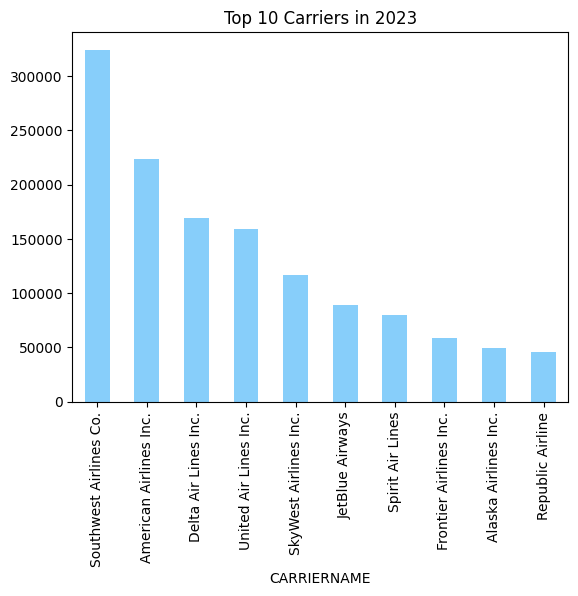

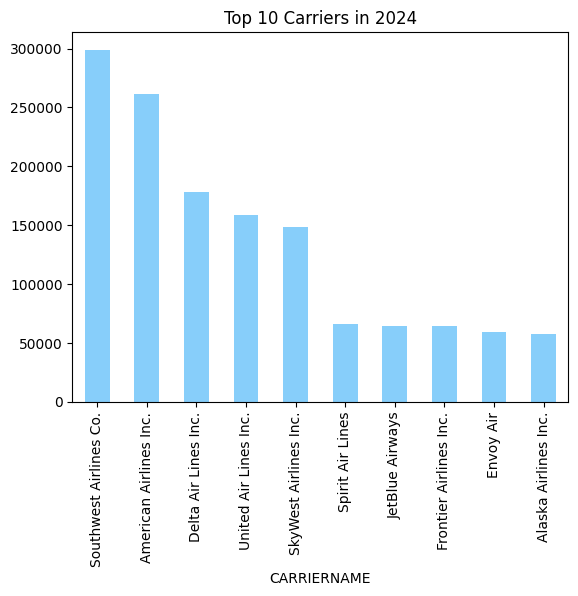

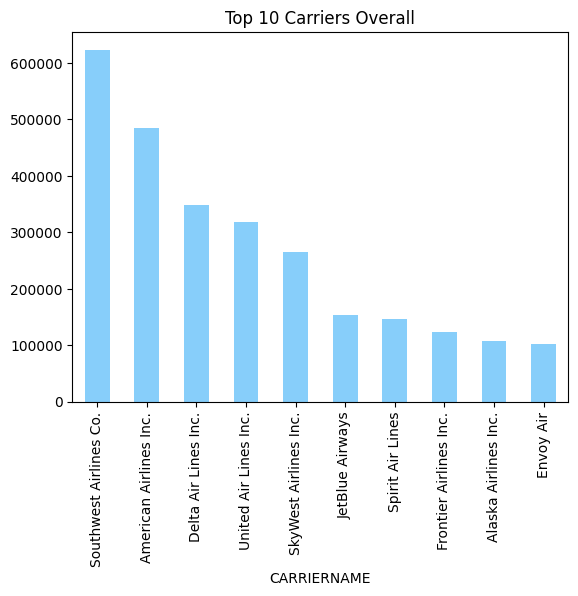

In [64]:
#CARRIER ANALYSIS II- TOP 10 CARRIERS
top10_car2023 = data23["CARRIERNAME"].value_counts().head(10)
top10_car2023bar = top10_car2023.plot(kind='bar', color="lightskyblue")
plt.title('Top 10 Carriers in 2023')
plt.show()
top10_car2024 = data24["CARRIERNAME"].value_counts().head(10)
top10_car2024bar = top10_car2024.plot(kind='bar', color="lightskyblue")
plt.title('Top 10 Carriers in 2024')
plt.show()
top10_total = data["CARRIERNAME"].value_counts().head(10)
top10_totalbar = top10_total.plot(kind='bar', color="lightskyblue")
plt.title('Top 10 Carriers Overall')
plt.show()

Text(0, 0.5, 'Total Delay Minutes')

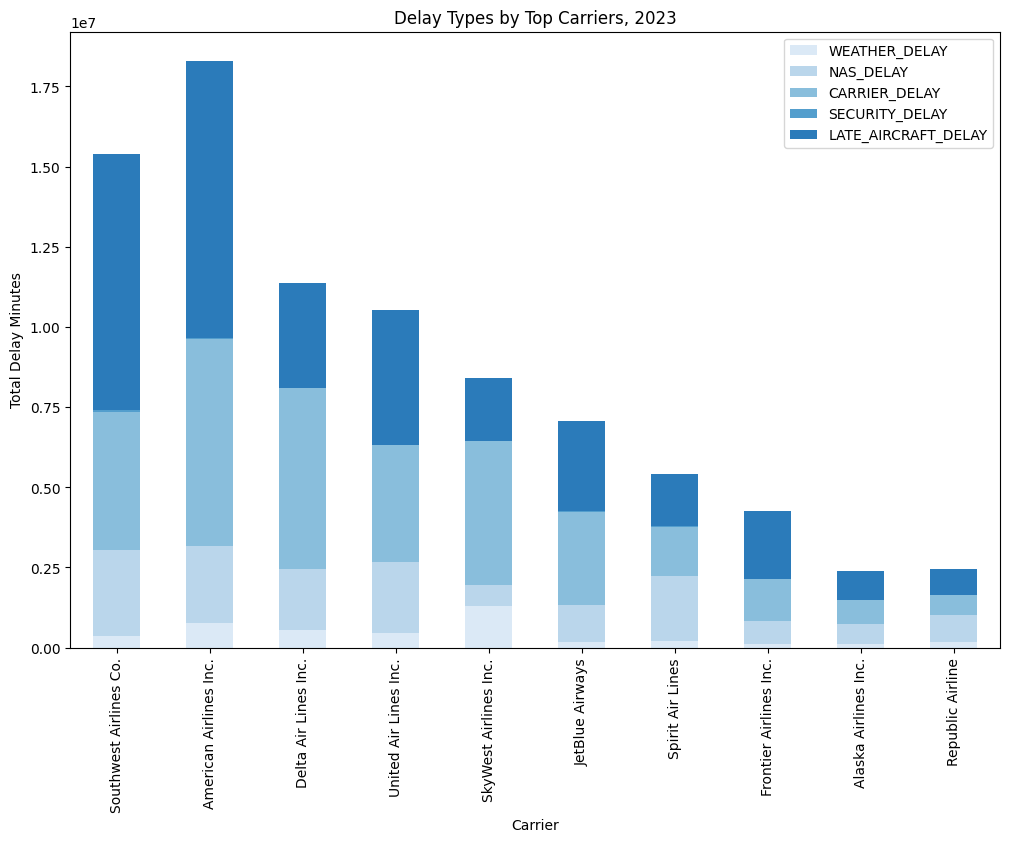

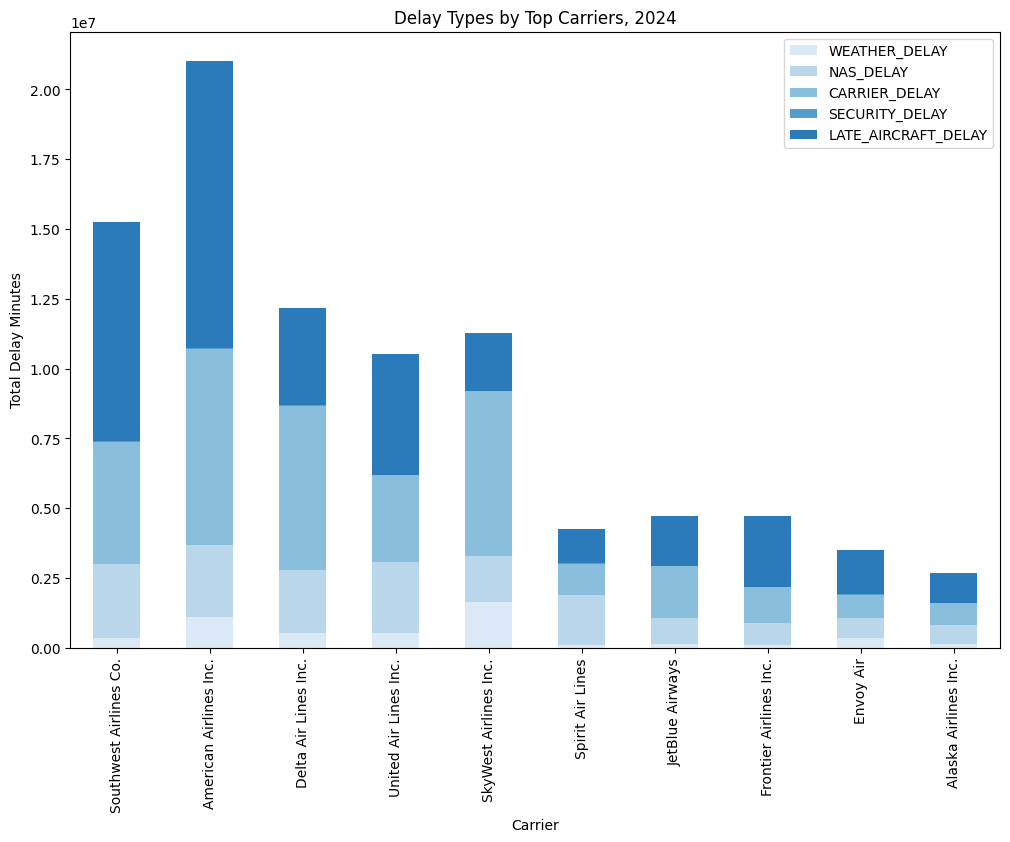

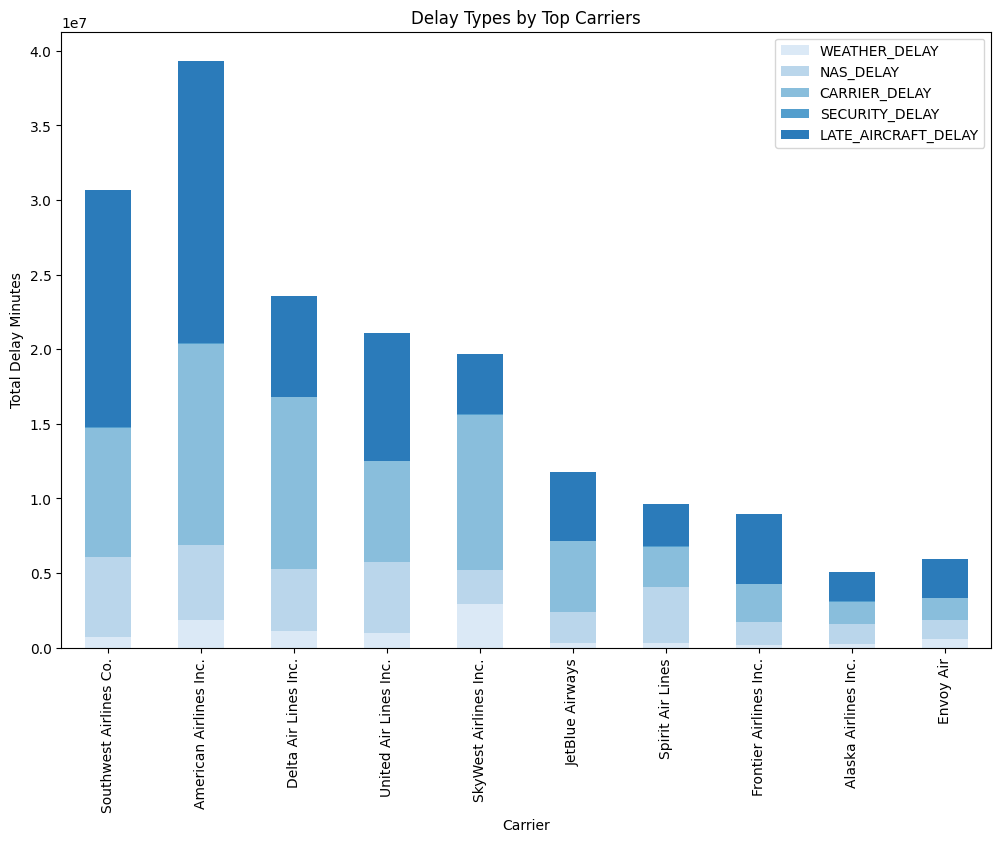

In [60]:
#CARRIER ANALYSIS III- DELAY TYPES BY CARRIER
top_carriers23 = top10_car2023.index.tolist()
delay_types = ['WEATHER_DELAY', 'NAS_DELAY', 'CARRIER_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
carrier_delay_summary23 = data23.groupby('CARRIERNAME')[delay_types].sum()
carrier_delay_summary23 = carrier_delay_summary23.loc[top_carriers23]
carrier_delay_summary23.plot(kind='bar', stacked=True, figsize=(12, 8), color=sns.color_palette('Blues'))
plt.title('Delay Types by Top Carriers, 2023')
plt.xlabel('Carrier')
plt.ylabel('Total Delay Minutes')

top_carriers24 = top10_car2024.index.tolist()
delay_types = ['WEATHER_DELAY', 'NAS_DELAY', 'CARRIER_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
carrier_delay_summary24 = data24.groupby('CARRIERNAME')[delay_types].sum()
carrier_delay_summary24 = carrier_delay_summary24.loc[top_carriers24]
carrier_delay_summary24.plot(kind='bar', stacked=True, figsize=(12, 8), color=sns.color_palette('Blues'))
plt.title('Delay Types by Top Carriers, 2024')
plt.xlabel('Carrier')
plt.ylabel('Total Delay Minutes')

top_carriers = top10_total.index.tolist()
delay_types = ['WEATHER_DELAY', 'NAS_DELAY', 'CARRIER_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
carrier_delay_summary = data.groupby('CARRIERNAME')[delay_types].sum()
carrier_delay_summary = carrier_delay_summary.loc[top_carriers]
carrier_delay_summary.plot(kind='bar', stacked=True, figsize=(12, 8), color=sns.color_palette('Blues'))
plt.title('Delay Types by Top Carriers')
plt.xlabel('Carrier')
plt.ylabel('Total Delay Minutes')

In [73]:
top9names = ["Southwest Airlines Co.", "American Airlines Inc.", "Delta Air Lines Inc.", "United Air Lines Inc.", "SkyWest Airlines Inc.", "JetBlue Airways", "Spirit Air Lines", "Frontier Airlines Inc.", "Alaska Airlines Inc."]
top923 = data23[data23["CARRIERNAME"].isin(top9names)]
top924 = data24[data24["CARRIERNAME"].isin(top9names)]
top9total = data[data["CARRIERNAME"].isin(top9names)]
top923["DELAYED"].value_counts()

DELAYED
True     1200707
False      68841
Name: count, dtype: int64

In [75]:
#percentage of flights delayed vs cancelled by carrier
def calculate_delay_percentage(df):
    total_flights = df["CARRIERNAME"].value_counts()
    delayed_flights = df[df["DELAYED"]==True]["CARRIERNAME"].value_counts()
    delay_percentage = (delayed_flights / total_flights) * 100
    return delay_percentage.sort_values(ascending=False)

print(calculate_delay_percentage(top923))
print(calculate_delay_percentage(top924))
print(calculate_delay_percentage(top9total))

CARRIERNAME
Alaska Airlines Inc.      96.016121
Southwest Airlines Co.    95.582630
American Airlines Inc.    95.542113
Spirit Air Lines          94.386465
Delta Air Lines Inc.      94.082931
JetBlue Airways           93.547412
United Air Lines Inc.     93.526876
Frontier Airlines Inc.    93.526476
SkyWest Airlines Inc.     92.907728
Name: count, dtype: float64
CARRIERNAME
Southwest Airlines Co.    95.854557
Delta Air Lines Inc.      94.592988
American Airlines Inc.    94.480431
SkyWest Airlines Inc.     94.474321
JetBlue Airways           92.947362
United Air Lines Inc.     91.997277
Frontier Airlines Inc.    91.779112
Spirit Air Lines          91.661006
Alaska Airlines Inc.      91.518090
Name: count, dtype: float64
CARRIERNAME
Southwest Airlines Co.    95.713122
American Airlines Inc.    94.970519
Delta Air Lines Inc.      94.344627
SkyWest Airlines Inc.     93.786777
Alaska Airlines Inc.      93.600881
JetBlue Airways           93.296268
Spirit Air Lines          93.151200
United A

Text(0.5, 1.0, 'Top 10 Airports by Carrier, 2023')

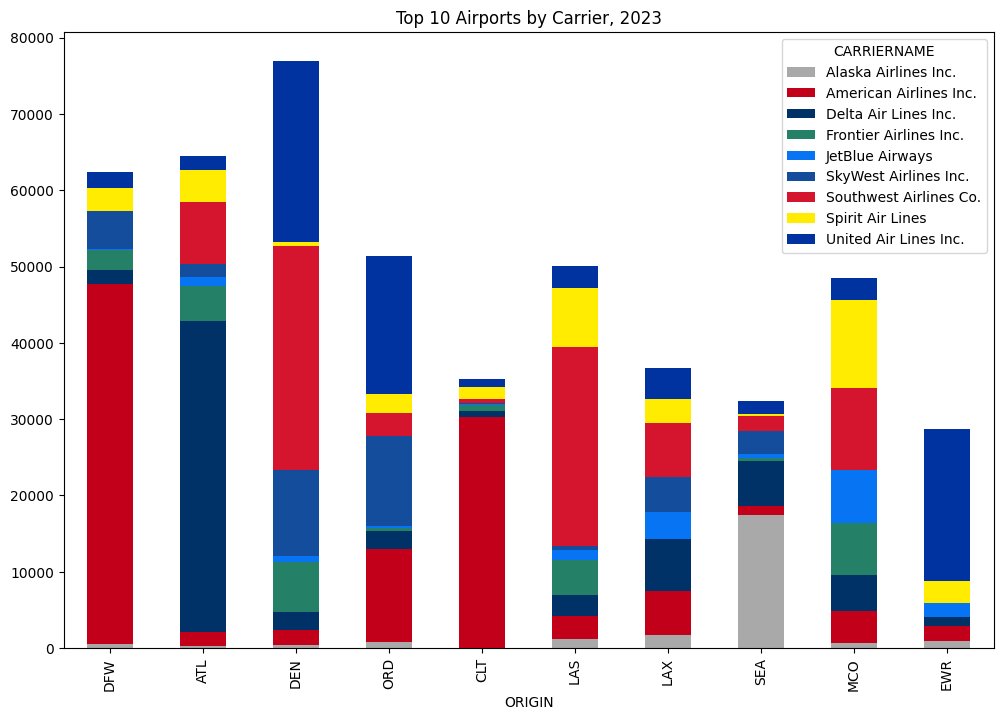

In [80]:
#airport by carrier analysis?

carrier_colors = {"Alaska Airlines Inc.": "darkgray", "American Airlines Inc.": "#C30019", "Delta Air Lines Inc.": "#003268", "Frontier Airlines Inc.": "#248168", "JetBlue Airways": "#0674F3", "SkyWest Airlines Inc.": "#154d9d", "Spirit Air Lines": "#FFEC00", "United Air Lines Inc.": "#0033A0", "Southwest Airlines Co.": "#D5152E"}

top10_airports_carrier23 = top923.groupby(['ORIGIN', 'CARRIERNAME']).size().unstack(fill_value=0)
top10_airports_carrier23 = top10_airports_carrier23.loc[top10_codes]
top10_airports_carrier23.plot(kind='bar', stacked=True, figsize=(12, 8), color=[carrier_colors.get(col) for col in top10_airports_carrier23.columns])
plt.title('Top 10 Airports by Carrier, 2023')

Text(0.5, 1.0, 'Top 3 Carriers at Each Airport, Overall')

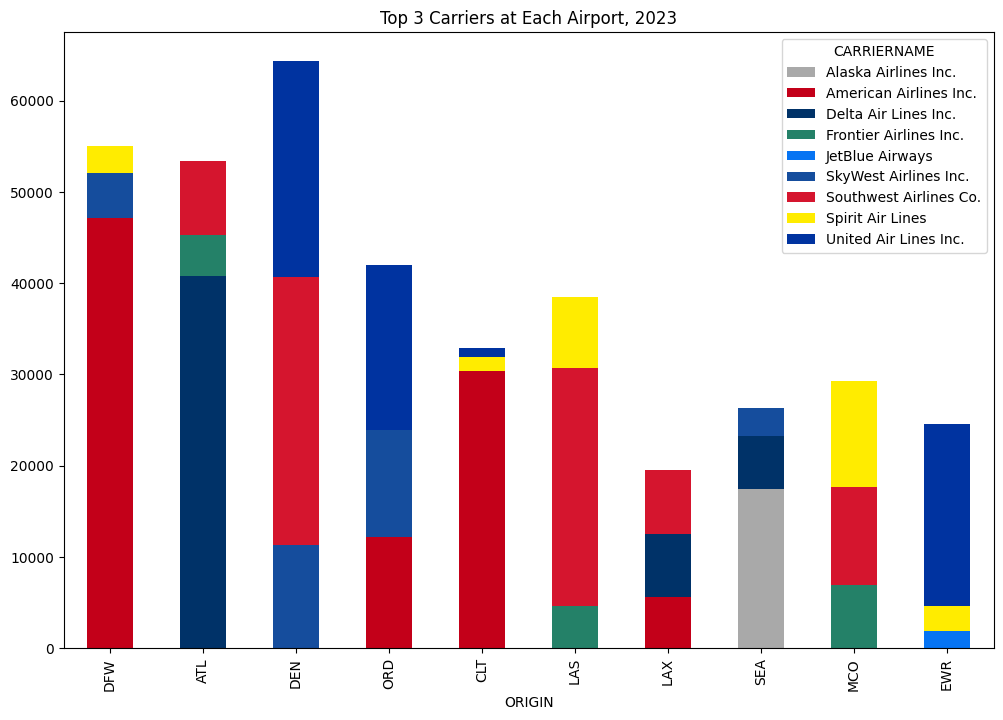

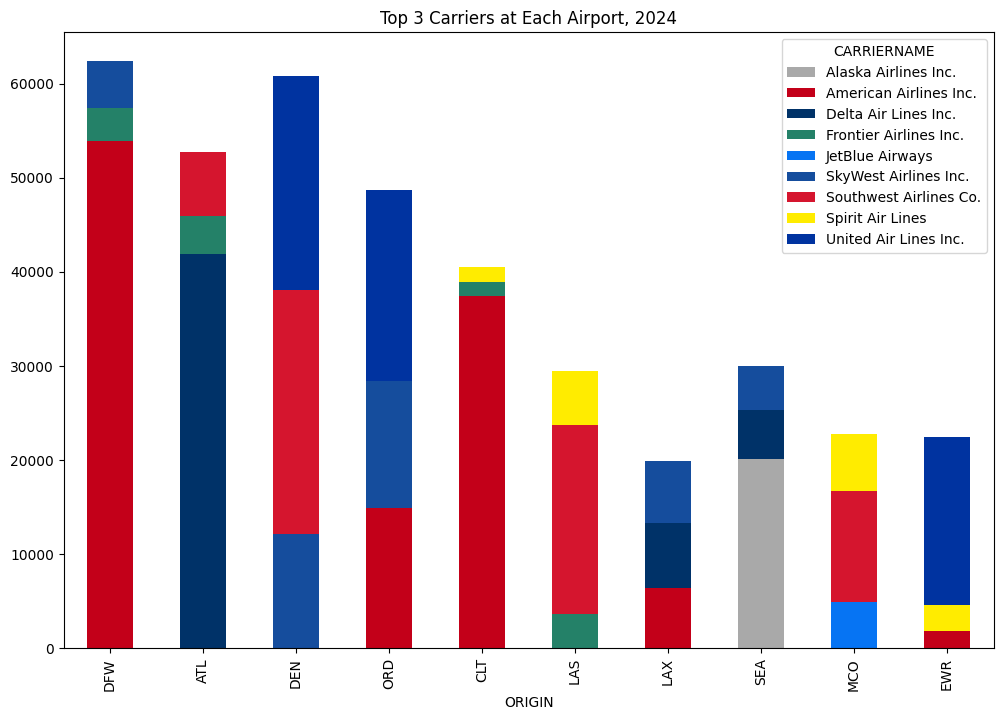

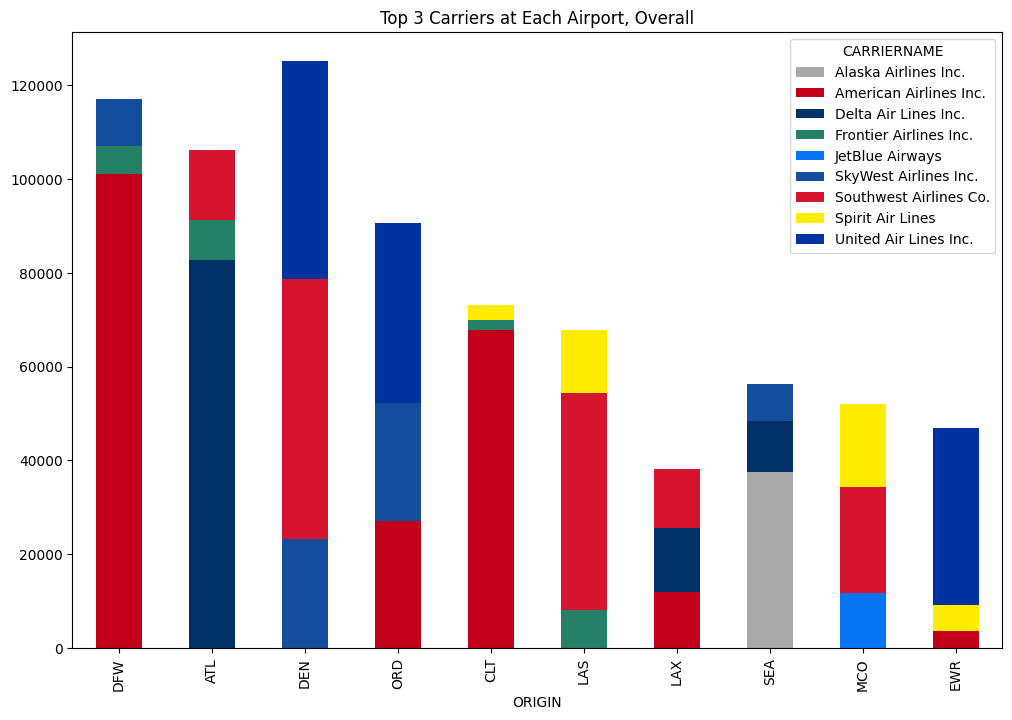

In [83]:
#top 3 carriers at each airport
top3_carriers_airport23 = top923.groupby(['ORIGIN', 'CARRIERNAME']).size().unstack(fill_value=0)
top3_carriers_airport23 = top3_carriers_airport23.loc[top10_codes]
top3_carriers_airport23 = top3_carriers_airport23.apply(lambda x: x.nlargest(3), axis=1)
top3_carriers_airport23.plot(kind='bar', stacked=True, figsize=(12, 8), color=[carrier_colors.get(col) for col in top3_carriers_airport23.columns])
plt.title('Top 3 Carriers at Each Airport, 2023')
top3_carriers_airport24 = top924.groupby(['ORIGIN', 'CARRIERNAME']).size().unstack(fill_value=0)
top3_carriers_airport24 = top3_carriers_airport24.loc[top10_codes]
top3_carriers_airport24 = top3_carriers_airport24.apply(lambda x: x.nlargest(3), axis=1)
top3_carriers_airport24.plot(kind='bar', stacked=True, figsize=(12, 8), color=[carrier_colors.get(col) for col in top3_carriers_airport24.columns])
plt.title('Top 3 Carriers at Each Airport, 2024')
top3_carriers_airporttotal = top9total.groupby(['ORIGIN', 'CARRIERNAME']).size().unstack(fill_value=0)
top3_carriers_airporttotal = top3_carriers_airporttotal.loc[top10_codes]
top3_carriers_airporttotal = top3_carriers_airporttotal.apply(lambda x: x.nlargest(3), axis=1)
top3_carriers_airporttotal.plot(kind='bar', stacked=True, figsize=(12, 8), color=[carrier_colors.get(col) for col in top3_carriers_airporttotal.columns])
plt.title('Top 3 Carriers at Each Airport, Overall')
